# Link-First Mechanism Builder

The `MechanismBuilder` uses a **link-first** approach to defining planar
mechanisms: you define links with their intrinsic properties (lengths, port
geometry) first, then connect them with joints. Joint positions are computed
automatically during assembly.

This is the inverse of the **legacy joint-first API** where you create joints
individually with explicit positions and parent references. The builder pattern
is more natural for mechanism design because you think in terms of rigid bodies
(links) and their connections, not isolated points.

This notebook covers:
1. Building a four-bar linkage with the builder API
2. Comparing with the legacy joint-first API
3. JSON serialization round-trip
4. Building a slider-crank mechanism

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

from pylinkage import extract_trajectory
from pylinkage.mechanism import (
    MechanismBuilder,
    fourbar,
    mechanism_from_json,
    mechanism_to_json,
    mechanism_to_linkage,
    slider_crank,
)
from pylinkage.synthesis import fourbar_from_lengths

## 1. Build a Four-Bar with the Builder API

A four-bar linkage has four links: ground, crank, coupler, and rocker.
With the builder, we define each link by its length and then connect
ports with `connect()`. Port naming convention:

- **Ground link** ports are named explicitly (e.g., `"A"`, `"D"`)
- **Driver link** ports are `"motor"` (at ground) and `"tip"` (output)
- **Binary links** have ports `"0"` and `"1"`

In [2]:
# Link lengths for a Grashof crank-rocker
CRANK = 1.0
COUPLER = 3.0
ROCKER = 3.0
GROUND = 4.0
OMEGA = 2 * math.pi / 100  # full rotation in 100 steps

builder = MechanismBuilder(name="four-bar")
builder.add_ground_link("ground", ports={"A": (0, 0), "D": (GROUND, 0)})
builder.add_driver_link("crank", length=CRANK, motor_port="A", omega=OMEGA)
builder.add_link("coupler", length=COUPLER)
builder.add_link("rocker", length=ROCKER)
builder.connect("crank.tip", "coupler.0")
builder.connect("coupler.1", "rocker.0")
builder.connect("rocker.1", "ground.D")

# Circle-circle intersection yields two assembly configurations.
# Branch 1 selects the upper (positive y) configuration, matching
# the convention used by fourbar_from_lengths().
builder.set_branch("coupler.1", 1)

mechanism = builder.build()
print(f"Mechanism: {mechanism.name}")
print(f"Joints ({len(mechanism.joints)}): {[j.id for j in mechanism.joints]}")
print(f"Links  ({len(mechanism.links)}): {[lnk.id for lnk in mechanism.links]}")

Mechanism: four-bar
Joints (4): ['coupler.0_crank.tip', 'coupler.1_rocker.0', 'ground.D_rocker.1', 'crank.motor_ground.A']
Links  (4): ['ground', 'crank', 'coupler', 'rocker']


### Shortcut: `pylinkage.mechanism.fourbar`

The eight-line builder chain above is the canonical pattern for a four-bar.
`pylinkage.mechanism.fourbar()` collapses it to a single call, returning the
same `Mechanism`. Use it whenever you don't need to customize port names or
add tracker/cam links — the verbose `MechanismBuilder` form is for everything
beyond the standard topologies.

In [3]:
# Same mechanism as above, in one line
mechanism_short = fourbar(
    crank=CRANK, coupler=COUPLER, rocker=ROCKER, ground=GROUND, omega=OMEGA,
    name="four-bar",
)
print(f"Joints: {[j.id for j in mechanism_short.joints]}")
print(f"Links:  {[lnk.id for lnk in mechanism_short.links]}")

Joints: ['coupler.0_crank.tip', 'coupler.1_rocker.0', 'ground.D_rocker.1', 'crank.motor_ground.A']
Links:  ['ground', 'crank', 'coupler', 'rocker']


## 2. Simulate and Plot

The `Mechanism.step()` generator yields joint coordinates for each
simulation step over one full rotation cycle.

In [4]:
# Simulate one full rotation
loci = list(mechanism.step())

print(f"Simulation steps: {len(loci)}")
print(f"Joints per step: {len(loci[0])}")

Simulation steps: 99
Joints per step: 4


Joint IDs: ['coupler.0_crank.tip', 'coupler.1_rocker.0', 'ground.D_rocker.1', 'crank.motor_ground.A']


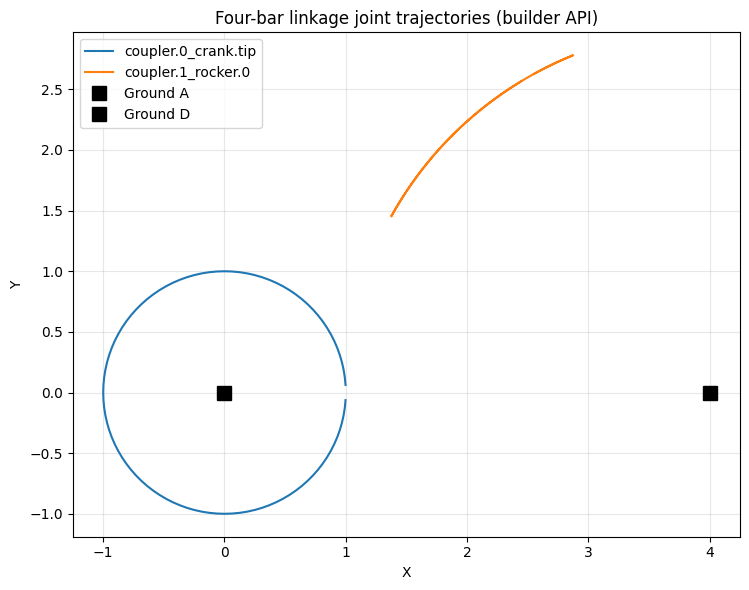

In [5]:
# Extract coupler joint trajectory (the joint connecting coupler and rocker)
# Find it by looking for the revolute joint that is not on the ground
# In a four-bar, the coupler point is the joint shared by coupler and rocker
joint_names = [j.id for j in mechanism.joints]
print(f"Joint IDs: {joint_names}")

# Collect all joint trajectories
trajectories = {}
for i, joint in enumerate(mechanism.joints):
    xs = [step[i][0] for step in loci if step[i][0] is not None]
    ys = [step[i][1] for step in loci if step[i][1] is not None]
    trajectories[joint.id] = (xs, ys)

fig, ax = plt.subplots(figsize=(8, 6))
for jid, (xs, ys) in trajectories.items():
    if len(set(zip(xs, ys, strict=False))) > 1:  # skip fixed points
        ax.plot(xs, ys, linewidth=1.5, label=jid)

# Mark ground pivots
ax.plot(0, 0, 'ks', markersize=10, label='Ground A')
ax.plot(GROUND, 0, 'ks', markersize=10, label='Ground D')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Four-bar linkage joint trajectories (builder API)')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Convert to Legacy Linkage

The builder creates a `Mechanism` (links + joints model). We can convert
it to the legacy `Linkage` (Assur-group model) for use with existing code.

In [6]:
legacy = mechanism_to_linkage(mechanism)

print(f"Legacy joints: {[j.name for j in legacy.joints]}")
print(f"Constraints:   {legacy.get_num_constraints()}")

# Simulate the legacy linkage
legacy_loci = list(legacy.step())
print(f"Legacy simulation steps: {len(legacy_loci)}")

Legacy joints: ['ground.D_rocker.1', 'crank.motor_ground.A', 'coupler.0_crank.tip', 'coupler.1_rocker.0']
Constraints:   [1.0, 3.0, 3.0]
Legacy simulation steps: 100


/home/h/Documents/dev/hu/the-great-walker/pylinkage/src/pylinkage/linkage/linkage.py:272: UserWarning: Automatic solving order is still in experimental stage!
  self.__find_solving_order__()


## 4. Validation: Compare with Legacy API

Build the same four-bar using `fourbar_from_lengths()` (the legacy
joint-first API) and overlay both coupler curves. The two APIs define
the same geometry, so the coupler curves should be identical in shape.

Note: the Mechanism simulator and the legacy Linkage simulator manage
internal state slightly differently (step count, phase offset), so we
compare the curve shapes visually rather than exact point-by-point values.

In [7]:
legacy_direct = fourbar_from_lengths(
    crank_length=CRANK,
    coupler_length=COUPLER,
    rocker_length=ROCKER,
    ground_length=GROUND,
    iterations=100,
    name="fourbar_legacy",
)

print(f"Legacy direct joints: {[j.name for j in legacy_direct.components]}")
print(f"Legacy direct constraints: {legacy_direct.get_num_constraints()}")

Legacy direct joints: ['A', 'D', 'B', 'C']
Legacy direct constraints: [1.0, 3.0, 3.0]


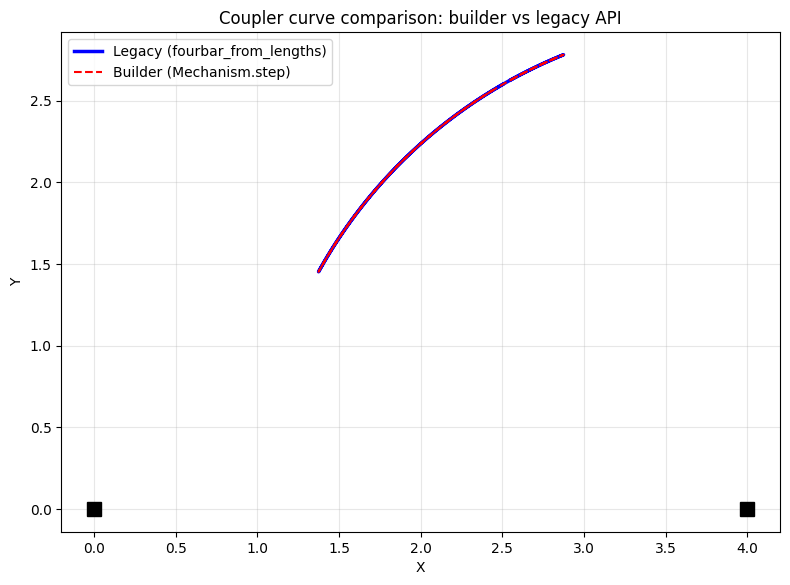

In [8]:
# Simulate both
direct_loci = list(legacy_direct.step(iterations=100))

# Extract coupler point (last joint = C) from legacy direct
dx, dy = extract_trajectory(direct_loci)

# From the builder mechanism, extract the coupler-rocker joint trajectory
mech_coupler_idx = next(
    i for i, joint in enumerate(mechanism.joints) if "coupler.1" in joint.id
)
cx, cy = extract_trajectory(loci, joint=mech_coupler_idx)

fig, ax = plt.subplots(figsize=(8, 6))

if dx.size:
    ax.plot(dx, dy, 'b-', linewidth=2.5, label='Legacy (fourbar_from_lengths)')

if cx.size:
    ax.plot(cx, cy, 'r--', linewidth=1.5, label='Builder (Mechanism.step)')

ax.plot(0, 0, 'ks', markersize=10)
ax.plot(GROUND, 0, 'ks', markersize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Coupler curve comparison: builder vs legacy API')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Quantitative shape comparison: for each point on one curve, find the
# nearest point on the other curve (Hausdorff-style comparison).
if dx.size and cx.size:
    direct_arr = np.column_stack([dx, dy])
    mech_arr = np.column_stack([cx, cy])

    # For each point on the mechanism curve, find min distance to legacy curve
    from scipy.spatial.distance import cdist
    dist_matrix = cdist(mech_arr, direct_arr)
    mech_to_direct = dist_matrix.min(axis=1)
    direct_to_mech = dist_matrix.min(axis=0)

    hausdorff = max(mech_to_direct.max(), direct_to_mech.max())
    print(f"Hausdorff distance between curves: {hausdorff:.6f}")
    print(f"Mean nearest-point distance:       {mech_to_direct.mean():.6f}")
    if hausdorff < 0.1:
        print("Both curves trace the same geometric path.")
    else:
        print("Curves differ -- check assembly configuration (set_branch).")
else:
    print("Could not compare (empty trajectory)")

Hausdorff distance between curves: 0.021277
Mean nearest-point distance:       0.000000
Both curves trace the same geometric path.


## 5. Serialization Round-Trip

Mechanisms can be saved to JSON and loaded back. This is useful for
storing designs and sharing them between tools.

In [10]:
import json
import tempfile
from pathlib import Path

from pylinkage.mechanism import mechanism_to_dict

# Inspect the serialized format
data = mechanism_to_dict(mechanism)
print(json.dumps(data, indent=2))

{
  "name": "four-bar",
  "joints": [
    {
      "id": "coupler.0_crank.tip",
      "type": "revolute",
      "position": [
        0.998026728428271,
        -0.06279051952932213
      ]
    },
    {
      "id": "coupler.1_rocker.0",
      "type": "revolute",
      "position": [
        2.4446986918578113,
        2.565353355951417
      ]
    },
    {
      "id": "ground.D_rocker.1",
      "type": "ground",
      "position": [
        4.0,
        0
      ]
    },
    {
      "id": "crank.motor_ground.A",
      "type": "ground",
      "position": [
        0,
        0
      ]
    }
  ],
  "links": [
    {
      "id": "ground",
      "type": "ground",
      "joints": [
        "crank.motor_ground.A",
        "ground.D_rocker.1"
      ]
    },
    {
      "id": "crank",
      "type": "driver",
      "joints": [
        "crank.motor_ground.A",
        "coupler.0_crank.tip"
      ],
      "angular_velocity": 0.06283185307179587,
      "initial_angle": 0.0,
      "motor_joint": "crank.m

In [11]:
# Save to a temporary file and load back
with tempfile.NamedTemporaryFile(suffix=".json", delete=False) as f:
    tmp_path = Path(f.name)

mechanism_to_json(mechanism, tmp_path)
loaded = mechanism_from_json(tmp_path)

print(f"Loaded mechanism: {loaded.name}")
print(f"Joints: {[j.id for j in loaded.joints]}")
print(f"Links:  {[lnk.id for lnk in loaded.links]}")

# Clean up
tmp_path.unlink()

Loaded mechanism: four-bar
Joints: ['coupler.0_crank.tip', 'coupler.1_rocker.0', 'ground.D_rocker.1', 'crank.motor_ground.A']
Links:  ['ground', 'crank', 'coupler', 'rocker']


In [12]:
# Verify the loaded mechanism produces identical trajectory
loaded_loci = list(loaded.step())

print(f"Original steps: {len(loci)}, Loaded steps: {len(loaded_loci)}")

# Compare joint positions at each step
n_steps = min(len(loci), len(loaded_loci))
max_diff = 0.0
for i in range(n_steps):
    for j in range(len(loci[i])):
        ox, oy = loci[i][j]
        lx, ly = loaded_loci[i][j]
        if ox is not None and lx is not None:
            diff = math.sqrt((ox - lx) ** 2 + (oy - ly) ** 2)
            max_diff = max(max_diff, diff)

print(f"Max position difference after round-trip: {max_diff:.10f}")
assert max_diff < 1e-6, "Round-trip serialization introduced errors!"
print("Serialization round-trip: PASSED")

Original steps: 99, Loaded steps: 99
Max position difference after round-trip: 0.0000000000
Serialization round-trip: PASSED


## 6. Advanced: Slider-Crank Mechanism

A slider-crank converts rotary motion into linear motion. The piston
(output) slides along a straight axis. This uses `add_slide_axis()` and
`connect_prismatic()` to define the prismatic (sliding) joint.

The `pylinkage.mechanism.slider_crank()` factory wraps the same builder
calls into a single helper for the canonical case.

In [13]:
CRANK_R = 1.0
ROD_LEN = 3.0
OMEGA_SC = 2 * math.pi / 100

sc_mech = slider_crank(crank=CRANK_R, rod=ROD_LEN, omega=OMEGA_SC)

print(f"Mechanism: {sc_mech.name}")
print(f"Joints ({len(sc_mech.joints)}): {[j.id for j in sc_mech.joints]}")
print(f"Links  ({len(sc_mech.links)}): {[lnk.id for lnk in sc_mech.links]}")

Mechanism: slider-crank
Joints (3): ['crank.tip_rod.0', 'crank.motor_ground.O', 'rod.1']
Links  (3): ['ground', 'crank', 'rod']


Simulation steps: 99


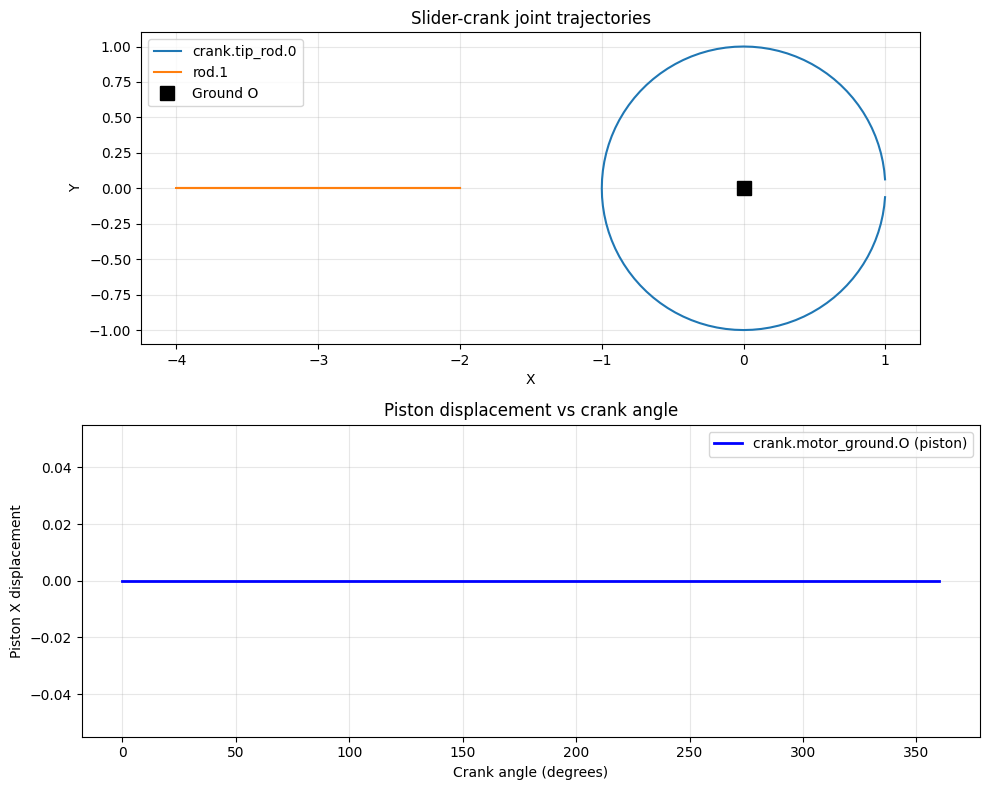

In [14]:
# Simulate
sc_loci = list(sc_mech.step())
print(f"Simulation steps: {len(sc_loci)}")

# Extract trajectories
sc_trajectories = {}
for i, joint in enumerate(sc_mech.joints):
    xs = [step[i][0] for step in sc_loci if step[i][0] is not None]
    ys = [step[i][1] for step in sc_loci if step[i][1] is not None]
    sc_trajectories[joint.id] = (xs, ys)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top: mechanism trajectories
for jid, (xs, ys) in sc_trajectories.items():
    if len(set(zip(xs, ys, strict=False))) > 1:
        ax1.plot(xs, ys, linewidth=1.5, label=jid)
ax1.plot(0, 0, 'ks', markersize=10, label='Ground O')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title('Slider-crank joint trajectories')
ax1.set_aspect('equal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: piston displacement over time
# The prismatic joint is the one constrained to the rail (rod.1)
# Find it: it has y ~ 0 throughout
for jid, (xs, ys) in sc_trajectories.items():
    if xs and all(abs(y) < 0.01 for y in ys):  # sliding joint stays on x-axis
        angles = np.linspace(0, 360, len(xs))
        ax2.plot(angles, xs, 'b-', linewidth=2, label=f'{jid} (piston)')
        ax2.set_xlabel('Crank angle (degrees)')
        ax2.set_ylabel('Piston X displacement')
        ax2.set_title('Piston displacement vs crank angle')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        break

plt.tight_layout()
plt.show()

## Summary

| Feature | Builder API | Legacy API |
|---|---|---|
| Define by | Links (rigid bodies) | Joints (connection points) |
| Joint positions | Computed automatically | Specified manually |
| Chaining | Fluent (`builder.add_...().connect_...()`) | Sequential |
| Port naming | `"link.port"` convention | Parent references |
| Prismatic joints | `add_slide_axis()` + `connect_prismatic()` | `Prismatic(...)` |
| Serialization | `mechanism_to_json()` / `mechanism_from_json()` | N/A |
| Conversion | `mechanism_to_linkage()` for legacy compat | Native |

For the canonical four-bar and slider-crank topologies, the
`pylinkage.mechanism.fourbar()` and `slider_crank()` factories collapse
the eight-line builder chain into a single call. Reach for
`MechanismBuilder` directly when you need port-name customization,
non-standard topologies, tracker joints, or cam followers.

The builder API is recommended for new mechanism designs. Use
`mechanism_to_linkage()` when you need to interoperate with existing
optimization or visualization code that expects the legacy `Linkage` type.